# **Modelo clasificatorio de calidad de champiñones**

In [1]:
# Instalación de librerías básicas
!pip install torch torchvision pandas numpy matplotlib scikit-learn seaborn

# **CARGAR DATOS Y ESTRATIFICACIÓN**

In [2]:
import pandas as pd

def load_data_from_github():
    try:
        #URLs Raw de archivos de github
        dataset_url = "https://raw.githubusercontent.com/VivianaPM/DL-VisNIR-QualityClassifier/refs/heads/feature/model-mushroom/Mushroom/Data/Dataset_Mus.csv"
        rangos_url = "https://raw.githubusercontent.com/VivianaPM/DL-VisNIR-QualityClassifier/refs/heads/feature/model-mushroom/Mushroom/Data/MushQualTags.csv"

        print("Cargando datos...")
        
        dataset = pd.read_csv(dataset_url, sep=',')
        rangos = pd.read_csv(rangos_url, sep=';')
        
        print(f"Dataset cargado: {dataset.shape}")
        print(f"Rangos cargados: {rangos.shape}")
        
        return dataset, rangos
        
    except Exception as e:
        print(f"Error: {e}")
        return None, None

## CREAR CSV DE PRUEBA DEL MODELO

In [3]:
def crear_test_rapido():
    dataset, _ = load_data_from_github()
    
    if dataset is not None:
        # Tomar 10 muestras, guardar solo Mush No, Dry matter y bandas
        test = dataset.sample(10, random_state=42)
        bandas = [c for c in test.columns if str(c).replace('.', '').isdigit() and c != 'Dry matter']
        test[['Mush No', 'Dry matter'] + sorted(bandas)].to_csv("test_rapido.csv", index=False)
        print("test_rapido.csv creado con 10 muestras")
        return True
    return False

# Ejecutar
crear_test_rapido()

Cargando datos...
Dataset cargado: (250, 206)
Rangos cargados: (6, 3)
test_rapido.csv creado con 10 muestras


True

## CARGAR DATOS DESDE GITHUB

In [4]:
df_Mush, rank_Mush = load_data_from_github()

if 'Dry matter' not in df_Mush.columns:
    print("Busca la columna equivalente a 'Dry matter' en:")
    print(df_Mush.columns.to_list())

Cargando datos...


Dataset cargado: (250, 206)
Rangos cargados: (6, 3)


In [5]:
display(rank_Mush)

,Category,Min_DryM,Max_DryM
0,Excelente,0.335,0.970
1,Muy buena,0.180,0.335
2,Buena,0.125,0.180
3,Razonable,0.089,0.125
4,Mala calidad,0.080,0.089
5,Muy mala,0.000,0.080


## ASIGNAR CATEGORÍA DEL MUSHQUALTAGS.CSV

In [6]:
def define_categories_mush(dry_matter, rank_Mush):
    for _, fila in rank_Mush.iterrows():
        if fila['Min_DryM'] <= dry_matter <= fila['Max_DryM']:
            return fila['Category']
    return 'Desconocida'

df_Mush['Category'] = df_Mush['Dry matter'].apply(
    lambda x: define_categories_mush(x, rank_Mush)
)

## DISTRIBUCIÓN DE CATEGORIAS

In [7]:
print(df_Mush['Category'].value_counts())

Category
Excelente       63
Razonable       62
Muy mala        51
Muy buena       36
Buena           26
Mala calidad    12
Name: count, dtype: int64


## CODIFICACIÓN TEMPORAL PARA ESTRATIFICAR

In [8]:
category_map_mush = {
    'Excelente': 0,
    'Razonable': 1,
    'Muy mala': 2,
    'Muy buena': 3,
    'Buena': 4,
    'Mala calidad': 5

}

df_Mush['strat_label'] = df_Mush['Category'].map(category_map_mush)

## Definición de X y Y globales

In [ ]:
X = df_Mush.drop(columns=['Category', 'strat_label'])
y = df_Mush['strat_label']

## CHEKPOINT: REVISAR CODIFICACIÓN TEMPORAL

In [ ]:
print(df_Mush[['Category', 'strat_label']].head())

       Category  strat_label
0  Mala calidad            5
1      Muy mala            2
2      Muy mala            2
3      Muy mala            2
4      Muy mala            2


# **DEFINICIÓN DE LA ARQUITECTURA DEL MLP**

In [11]:
import torch.nn as nn

class MLP_Mush(nn.Module):
    def __init__(self, input_size, hidden_layers, outputs_size, activation, dropout_rate=0.2):
        super().__init__()

        layers = []
        prev_size = input_size

        # Función de activación
        act_map = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid()
        }
        
        act = act_map[activation]

        # Hidden layers
        for h in hidden_layers:
            layers.append(nn.Linear(prev_size, h))
            layers.append(act)
            layers.append(nn.Dropout(dropout_rate))
            prev_size = h
        
        layers.append(nn.Linear(prev_size, outputs_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)
        

# **STRATIFIED K-FOLD**

In [12]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## CHECKPOINT: VALIDACIÓN DE FOLDS

In [13]:
from collections import defaultdict
import pandas as pd

fold_counts = []

for i, (train_idx, val_idx) in enumerate(
        skf.split(df_Mush, df_Mush['strat_label'])):

    print(f"\nFOLD {i+1}")

    train_counts = df_Mush.iloc[train_idx]['Category'].value_counts()
    val_counts   = df_Mush.iloc[val_idx]['Category'].value_counts()

    print("TRAIN\n", train_counts)
    print("VAL\n", val_counts)

    # Guardar ambos para luego promediar
    for cat in df_Mush['Category'].unique():

        fold_counts.append({
            "fold": i+1,
            "category": cat,
            "train_samples": train_counts.get(cat, 0),
            "val_samples": val_counts.get(cat, 0)
        })



FOLD 1
TRAIN
 Category
Excelente       51
Razonable       50
Muy mala        41
Muy buena       29
Buena           20
Mala calidad     9
Name: count, dtype: int64
VAL
 Category
Excelente       12
Razonable       12
Muy mala        10
Muy buena        7
Buena            6
Mala calidad     3
Name: count, dtype: int64

FOLD 2
TRAIN
 Category
Excelente       51
Razonable       50
Muy mala        41
Muy buena       28
Buena           21
Mala calidad     9
Name: count, dtype: int64
VAL
 Category
Razonable       12
Excelente       12
Muy mala        10
Muy buena        8
Buena            5
Mala calidad     3
Name: count, dtype: int64

FOLD 3
TRAIN
 Category
Excelente       50
Razonable       50
Muy mala        40
Muy buena       29
Buena           21
Mala calidad    10
Name: count, dtype: int64
VAL
 Category
Excelente       13
Razonable       12
Muy mala        11
Muy buena        7
Buena            5
Mala calidad     2
Name: count, dtype: int64

FOLD 4
TRAIN
 Category
Excelente       50
Raz

In [14]:
# Folds consolidados
fold_df = pd.DataFrame(fold_counts)
print(fold_df.head())

   fold      category  train_samples  val_samples
0     1  Mala calidad              9            3
1     1      Muy mala             41           10
2     1     Razonable             50           12
3     1         Buena             20            6
4     1     Muy buena             29            7


In [ ]:
mean_df = fold_df.groupby("category")[["train_samples", "val_samples"]].mean().reset_index()

mean_df.to_csv("prom_muestras_clase.csv", index=False)

## **GRAFICA DEL PROMEDIO DE MUESTRAS POR FOLDS**

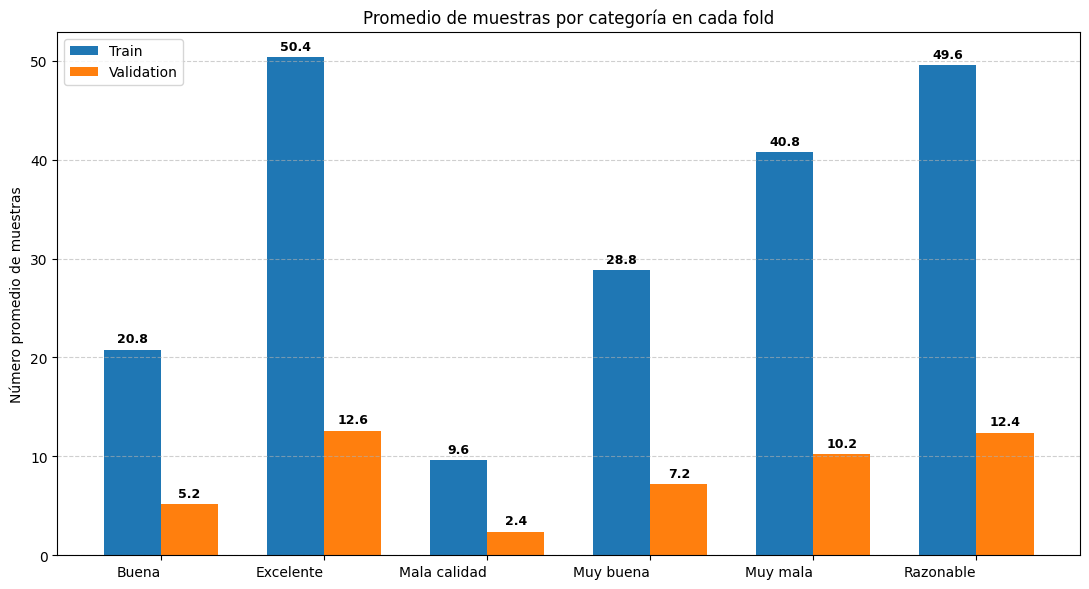

In [16]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(mean_df))
width = 0.35

plt.figure(figsize=(11,6))

# Barras
bars_train = plt.bar(
    x - width/2,
    mean_df["train_samples"],
    width,
    label="Train"
)

bars_val = plt.bar(
    x + width/2,
    mean_df["val_samples"],
    width,
    label="Validation"
)

# Etiquetas en cada barra
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(
            f'{height:.1f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),                 # desplazamiento vertical
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

autolabel(bars_train)
autolabel(bars_val)

# Ejes
plt.xticks(x, mean_df["category"], ha='right')
plt.ylabel("Número promedio de muestras")
plt.title("Promedio de muestras por categoría en cada fold")

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.legend()
plt.tight_layout()
plt.show()

# **ENTRENAMIENTO Y OPTIMIZACIÓN DEL MODELO**

## Diccionario de Optimizadores

In [ ]:
import torch.optim as optim 

OPTIMIZERS = {
    # ADAM
    'adam': lambda params, lr: optim.Adam(params, lr=lr),
    # SGD
    'sgd': lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9),
    # RMSprop
    'rmsprop': lambda params, lr: optim.RMSprop(params, lr=lr),
    # AdamW
    'adamW': lambda params, lr: optim.AdamW(params, lr=lr) 
}

## Dicionario de funciones de perdida

In [18]:
CRITERIONS = {
    # Entropia cruzada
    'cross_entropy': nn.CrossEntropyLoss, #Recomendada segun lo que he probado

    'weighted_ce': lambda w=None: nn.CrossEntropyLoss(weight=w),
    '''
    La pérdida de probabilidad logarítmica negativa. Es útil entrenar una clasificación problema con C clases. 
    (NLLLoss - Pytorch2.9 documentation, 2023)
    '''
    'nll': nn.NLLLoss,  
}

## FUNCIÓN DE ENTRENAMIENTO DEL MLP

In [19]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class Trainer:

    def __init__(self, model, device=None):

        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = model.to(self.device)

        self.history = {
            'train_loss': [],
            'train_accuracy': [],
            'val_loss': [],
            'val_accuracy': [],
            'val_precision': [],
            'val_recall': [],
            'val_f1': []
        }

    # SETUP
    def setup(self, 
              optimizer_name='adam', 
              criterion_name='cross_entropy', 
              lr=1e-4, 
              class_weight=None):

        if optimizer_name not in OPTIMIZERS:
            raise ValueError(f"Optimizador no soportado: {optimizer_name}")

        self.optimizer = OPTIMIZERS[optimizer_name](self.model.parameters(), lr)

        # Criterion
        if criterion_name == "weighted_ce":
            self.criterion = CRITERIONS["weighted_ce"](class_weight)
        else:
            self.criterion = CRITERIONS[criterion_name]()

    # TRAIN 1 EPOCH
    def train_epoch(self, loader):
        self.model.train()

        total_loss = 0
        correct = 0
        total = 0

        for x, y in loader:
            x = x.to(self.device)
            y = y.to(self.device)

            self.optimizer.zero_grad()

            logits = self.model(x)
            loss = self.criterion(logits, y)

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

        avg_loss = total_loss / len(loader)
        accuracy = correct / total

        return avg_loss, accuracy

    # VALIDATION
    def validate(self, loader):
        self.model.eval()

        total_loss = 0
        all_y = []
        all_pred = []

        with torch.no_grad():
            for x, y in loader:
                x = x.to(self.device)
                y = y.to(self.device)

                logits = self.model(x)
                loss = self.criterion(logits, y)

                preds = logits.argmax(dim=1)

                total_loss += loss.item()

                all_y.extend(y.cpu().numpy())
                all_pred.extend(preds.cpu().numpy())

        acc = accuracy_score(all_y, all_pred)
        prec = precision_score(all_y, all_pred, average='macro', zero_division=0)
        rec = recall_score(all_y, all_pred, average='macro', zero_division=0)
        f1 = f1_score(all_y, all_pred, average='macro', zero_division=0)

        return total_loss / len(loader), acc, prec, rec, f1

    # FULL TRAINING LOOP
    def train(self, train_loader, val_loader, epochs=50):

        for epoch in range(epochs):

            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, acc, prec, rec, f1 = self.validate(val_loader)

            self.history['train_loss'].append(train_loss)
            self.history['train_accuracy'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_accuracy'].append(acc)
            self.history['val_precision'].append(prec)
            self.history['val_recall'].append(rec)
            self.history['val_f1'].append(f1)

            if epoch % 10 == 0:
                print(
                    f"Epoch {epoch:03d} | "
                    f"Train: {train_loss:.3f} | "
                    f"Val: {val_loss:.3f} | "
                    f"Acc: {acc:.3f} | "
                    f"F1: {f1:.3f}"
                )

        return self.history
    
    # PREDICT FOR EVALUATION
    def predict(self, loader):

        self.model.eval()

        all_preds = []
        all_true = []

        with torch.no_grad():
            for x, y in loader:
                x = x.to(self.device)
                y = y.to(self.device)

                logits = self.model(x)
                preds = logits.argmax(dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_true.extend(y.cpu().numpy())

        return all_true, all_preds    


## DICCIONARIO DE OVERSAMPLERS

In [20]:
from imblearn.over_sampling import RandomOverSampler, SMOTE #instalar

OVERSAMPLERS = {
    "none": None, #Sin oversampling
    "ros": RandomOverSampler,
    'smote': SMOTE

}

## **FUNCIÓN DE OVERSAMPLING**

In [ ]:
def apply_oversampling(X, y, method="none", random_state=42):

    if method == "none":
        return X, y
    
    if method not in OVERSAMPLERS:
        raise ValueError(f"Oversampler no soportado {method}")
    
    sampler = OVERSAMPLERS[method](random_state=random_state)

    X_res, Y_res = sampler.fit_resample(X, y)

    return X_res, Y_res

## CONFIGURACION DE MLP

In [ ]:
MODEL_CONFIG = {
    "Modelo_P1_M": {
        "hidden_layers": [64],
        "activation": 'sigmoid',
        "dropout": 0.35,
        "epochs": 150,
        "oversamplers": 'ros',
        # función de optimización
        "optimizer":'adam', 
        "criterion": 'cross_entropy', 
        "lr": 1e-4, 
        "class_weight": None
    },

    "Modelo_PA_M": {
        "hidden_layers": [94, 32],
        "activation": 'tanh',
        "dropout": 0.2,
        "epochs": 100,
        "oversamplers": 'ros',
        # función de optimización
        "optimizer":'adamW', 
        "criterion": 'cross_entropy', 
        "lr": 1e-3, 
        "class_weight": None
    },

    "Modelo_M1": {
        "hidden_layers": [84],
        "activation": 'relu',
        "dropout": 0.2,
        "epochs": 120,
        "oversamplers": 'ros',
        # función de optimización
        "optimizer":'adam', 
        "criterion": 'cross_entropy', 
        "lr": 1e-3, 
        "class_weight": None
    },

    "Modelo_M2": {
        "hidden_layers": [128, 84],
        "activation": 'relu',
        "dropout": 0.2,
        "epochs": 140,
        "oversamplers": 'smote',
        # función de optimización
        "optimizer":'adam', 
        "criterion": 'weighted_ce', 
        "lr": 5e-4, 
        "class_weight": None
    },

    "Modelo_M3": {
        "hidden_layers": [128, 64],
        "activation": 'relu',
        "dropout": 0.2,
        "epochs": 140,
        "oversamplers": 'smote',
        # función de optimización
        "optimizer":'adam', 
        "criterion": 'cross_entropy', 
        "lr": 5e-4, 
        "class_weight": None
    },   

    "Modelo_M4": {
        "hidden_layers": [64],
        "activation": 'relu',
        "dropout": 0.3,
        "epochs": 120,
        "oversamplers": 'ros',
        # función de optimización
        "optimizer":'rmsprop', 
        "criterion": 'cross_entropy', 
        "lr": 1e-3, 
    "class_weight": None
    },   

}

## **LOOP PRINCIPAL PARA FOLDS**

In [23]:
from  torch.utils.data import DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
# Revisar lo que tengo en x y y
# print("X: ", X.shape)
# print("Y: ", y.shape)

trained_models = {}

for model_name, config in MODEL_CONFIG.items():

    print(f"EJECUTANDO {model_name}")
    # Lista de metricas para folds
    metrics_all_folds_mush = []
    train_losses_all = []
    val_losses_all = []
    all_y_true = []
    all_y_pred = []


# loop del fold
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

        print(f"{'='*7} FOLD {fold} {'='*7}")

        #Paso #1: División del df_Mush
        X_train = X.iloc[train_idx]
        X_val   = X.iloc[val_idx]

        Y_train = y.iloc[train_idx]
        Y_val   = y.iloc[val_idx]  

        #Paso #2: Limpieza de las bandas
        spectral_bands = [c for c in X_train.columns if c not in ['Mush No']] 

        X_train_clean = X_train[spectral_bands]
        X_val_clean = X_val[spectral_bands]

        #Paso 4: Definición de los inputs de la red (Bandas espectrales)
        num_feactures = X_train_clean.shape[1]

        #Paso 5: Normalización - Buscando mejorar el rendimiento del modelo
        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train_clean) 
        X_val_scaled = scaler.transform(X_val_clean)

        # Paso 6: OVERSAMPLING
        X_train_ros, Y_train_ros = apply_oversampling(
            X_train_scaled,
            Y_train,
            method=config['oversamplers']
        )

        # Paso 6.5 – Calcular pesos de clase
        classes = np.unique(Y_train_ros)
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=Y_train_ros
        )

        class_weights = torch.tensor(class_weights, dtype=torch.float32)  

        # Paso 7: Tensores
        X_train_tensor = torch.FloatTensor(X_train_ros)
        X_val_tensor = torch.FloatTensor(X_val_scaled)

        Y_train_tensor = torch.LongTensor(Y_train_ros.values)
        Y_val_tensor = torch.LongTensor(Y_val.values)

        # Paso 8: Creación de dataset y loader
        train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)

        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
        
        # Paso 9: Modelo + entrenamiento 
        model = MLP_Mush(
            input_size=num_feactures,
            hidden_layers=config['hidden_layers'],
            outputs_size=6,
            activation=config['activation'],       
            dropout_rate=config['dropout']    
        )

        trainer = Trainer(model)
        trained_models[model_name] = trainer
        trainer.setup(config['optimizer'], config['criterion'], config['lr'], class_weights)

        history = trainer.train(
            train_loader=train_loader,
            val_loader=val_loader,
            epochs = config['epochs']
        )

        y_true, y_pred = trainer.predict(val_loader)

        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)

        # Paso 10: Guardar metricas
        for epoch in range(len(history['train_loss'])):

            metrics_all_folds_mush.append({
                "model": model_name,
                "fold": fold + 1,
                "epoch": epoch,

                "train_loss": history["train_loss"][epoch],
                "train_accuracy": history["train_accuracy"][epoch],

                "val_loss": history["val_loss"][epoch],
                "val_accuracy": history["val_accuracy"][epoch],
                "val_precision": history["val_precision"][epoch],
                "val_recall": history["val_recall"][epoch],
                "val_f1": history["val_f1"][epoch]               
            })

    #EXPORTAR CSV DE METRICAS POR MODELO 
    df = pd.DataFrame(metrics_all_folds_mush)

    csv_filename = f"metrics_{model_name}.csv"

    df.to_csv(csv_filename, index=False)

    print(f"CSV guardado: {csv_filename}")
    
    #EXPORTAR CSV PARA MATRIX DE CONFUSION 
    csv_filename_con = f"confusion_{model_name}.csv"

    pd.DataFrame({
        'y_true': all_y_true,
        'y_pred': all_y_pred
    }).to_csv(csv_filename_con, index=False)

    print(f"CSV guardado: {csv_filename_con}")

EJECUTANDO Modelo_P1_M
======= FOLD 1 =======
Epoch 000 | Train: 1.855 | Val: 1.866 | Acc: 0.120 | F1: 0.036
Epoch 010 | Train: 1.724 | Val: 1.732 | Acc: 0.220 | F1: 0.139
Epoch 020 | Train: 1.692 | Val: 1.656 | Acc: 0.340 | F1: 0.227
Epoch 030 | Train: 1.618 | Val: 1.609 | Acc: 0.360 | F1: 0.275
Epoch 040 | Train: 1.587 | Val: 1.574 | Acc: 0.360 | F1: 0.268
Epoch 050 | Train: 1.568 | Val: 1.547 | Acc: 0.380 | F1: 0.279
Epoch 060 | Train: 1.549 | Val: 1.522 | Acc: 0.380 | F1: 0.279
Epoch 070 | Train: 1.544 | Val: 1.500 | Acc: 0.420 | F1: 0.321
Epoch 080 | Train: 1.503 | Val: 1.480 | Acc: 0.480 | F1: 0.382
Epoch 090 | Train: 1.496 | Val: 1.462 | Acc: 0.500 | F1: 0.402
Epoch 100 | Train: 1.472 | Val: 1.444 | Acc: 0.520 | F1: 0.421
Epoch 110 | Train: 1.482 | Val: 1.429 | Acc: 0.540 | F1: 0.434
Epoch 120 | Train: 1.440 | Val: 1.417 | Acc: 0.580 | F1: 0.461
Epoch 130 | Train: 1.433 | Val: 1.406 | Acc: 0.540 | F1: 0.440
Epoch 140 | Train: 1.449 | Val: 1.396 | Acc: 0.520 | F1: 0.428
======= F

## PROMEDIO POR METRICAS DE MODELO

In [24]:
model_files = {
    "P1_M": "metrics_Modelo_P1_M.csv",
    "PA_M": "metrics_Modelo_PA_M.csv",
    "M1": "metrics_Modelo_M1.csv",
    "M2": "metrics_Modelo_M2.csv",
    "M3": "metrics_Modelo_M3.csv",
    "M4": "metrics_Modelo_M4.csv",
}

def calcular_promedios_por_modelo(csv_path):

    df = pd.read_csv(csv_path)

    last_epochs = df.groupby("fold").tail(1)

    mean_metrics = last_epochs[
        ["val_accuracy", "val_precision", "val_recall", "val_f1"]
    ].mean()

    return mean_metrics

# EJECUCIÓN AUTOMÁTICA

for model_name, csv_file in model_files.items():
    print(f"\nMetricas del modelo {model_name}")
    result = calcular_promedios_por_modelo(csv_file)
    print(result)


Metricas del modelo P1_M
val_accuracy     0.472000
val_precision    0.346492
val_recall       0.429189
val_f1           0.362114
dtype: float64

Metricas del modelo PA_M
val_accuracy     0.756000
val_precision    0.711096
val_recall       0.704467
val_f1           0.696663
dtype: float64

Metricas del modelo M1
val_accuracy     0.680000
val_precision    0.621852
val_recall       0.627464
val_f1           0.604550
dtype: float64

Metricas del modelo M2
val_accuracy     0.748000
val_precision    0.684309
val_recall       0.700895
val_f1           0.681054
dtype: float64

Metricas del modelo M3
val_accuracy     0.720000
val_precision    0.661257
val_recall       0.685624
val_f1           0.655712
dtype: float64

Metricas del modelo M4
val_accuracy     0.680000
val_precision    0.641954
val_recall       0.640416
val_f1           0.617800
dtype: float64


## **COMPARACIÓN DE DESEMPEÑO ENTRE TRES MODELOS**

  Modelo  Accuracy  Precision    Recall        F1
0   P1_A  0.408293   0.282827  0.366050  0.289069
1     A4  0.586686   0.508866  0.545165  0.499143
2   PA_A  0.650840   0.597909  0.610185  0.576738


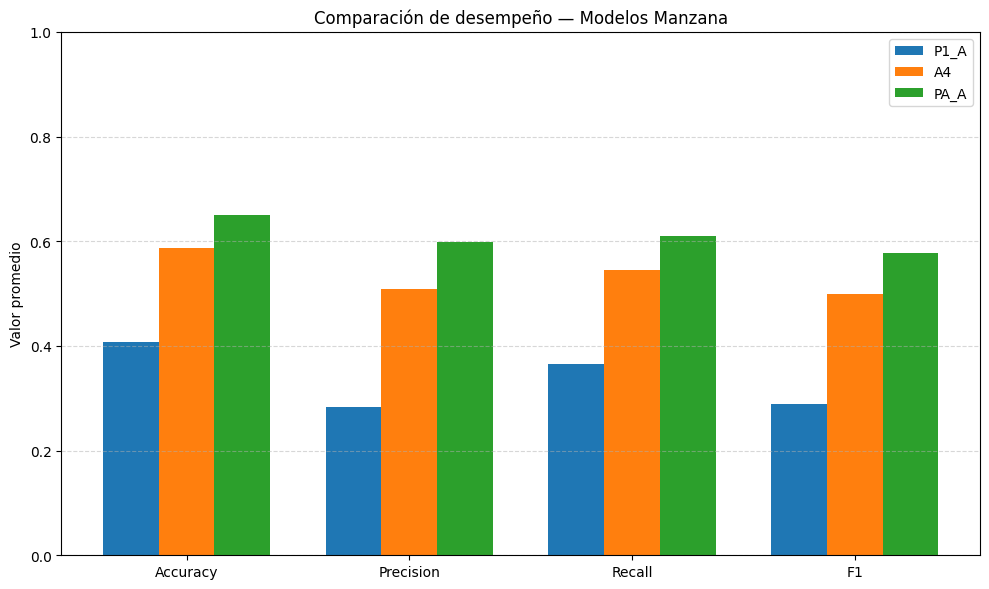

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    "P1_A": "metrics_Modelo_P1_M.csv",
    "A4":   "metrics_Modelo_M3.csv",
    "PA_A": "metrics_Modelo_PA_M.csv"
}

metrics = []

for name, file in files.items():
    df = pd.read_csv(file)

    # Promedio final entre todos los folds
    summary = df[[
        'val_accuracy',
        'val_precision',
        'val_recall',
        'val_f1'
    ]].mean()

    metrics.append({
        "Modelo": name,
        "Accuracy": summary['val_accuracy'],
        "Precision": summary['val_precision'],
        "Recall": summary['val_recall'],
        "F1": summary['val_f1']
    })

# Consolidar DataFrame final
final_df = pd.DataFrame(metrics)

print(final_df)

metrics_names = ["Accuracy", "Precision", "Recall", "F1"]

x = np.arange(len(metrics_names))
width = 0.25

plt.figure(figsize=(10, 6))

for i, model in enumerate(final_df['Modelo']):
    values = final_df.loc[
        final_df['Modelo'] == model,
        metrics_names
    ].values.flatten()

    plt.bar(x + i * width, values, width, label=model)

# Formato del gráfico
plt.xticks(x + width, metrics_names)
plt.ylim(0, 1)

plt.ylabel("Valor promedio")
plt.title("Comparación de desempeño — Modelos Manzana")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## GRAFICOS: TRAIN VS VAL (LOSS Y ACCUARY)

Graficas para el modelo P1_M


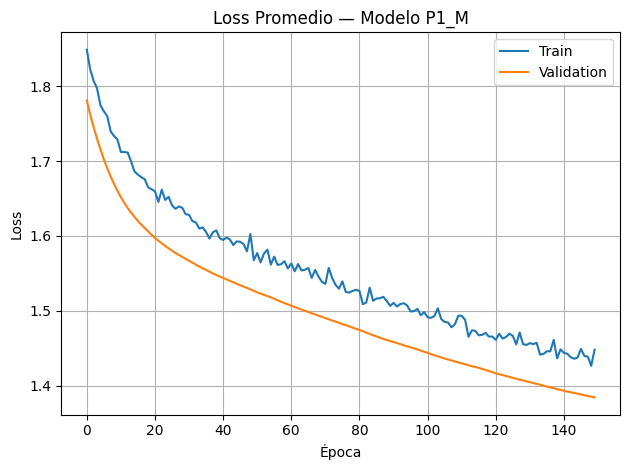

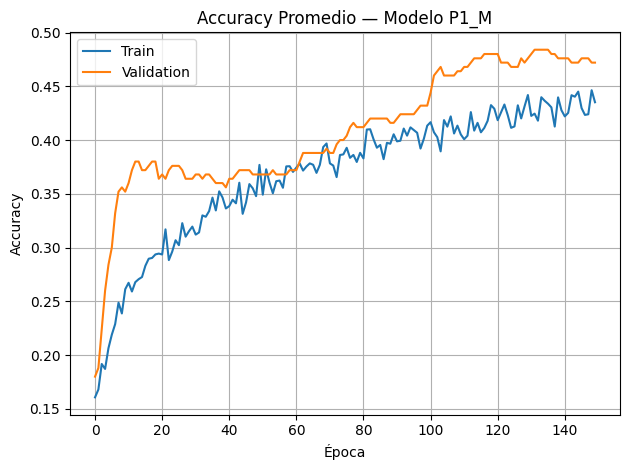

Graficas para el modelo PA_M


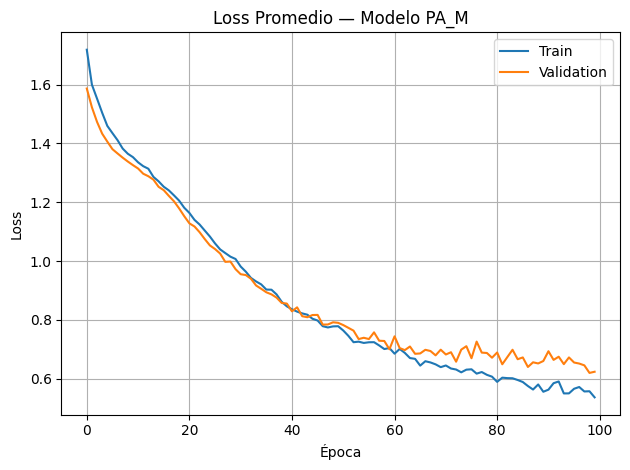

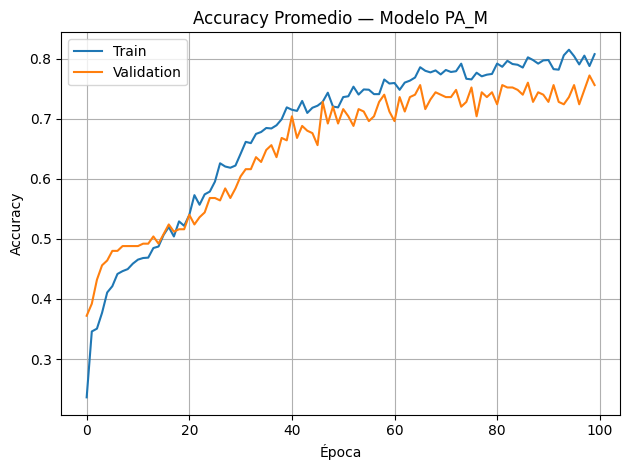

Graficas para el modelo M1


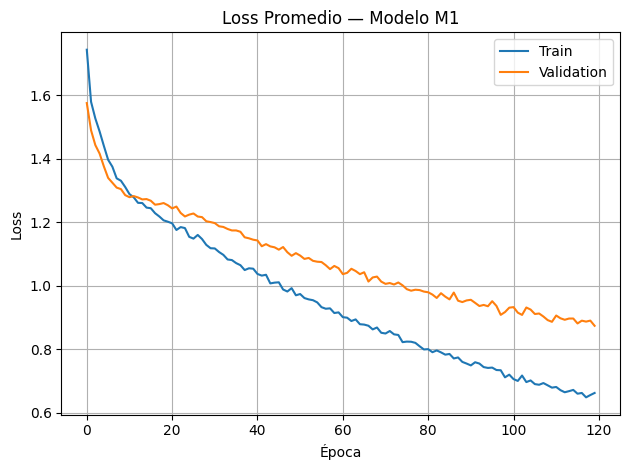

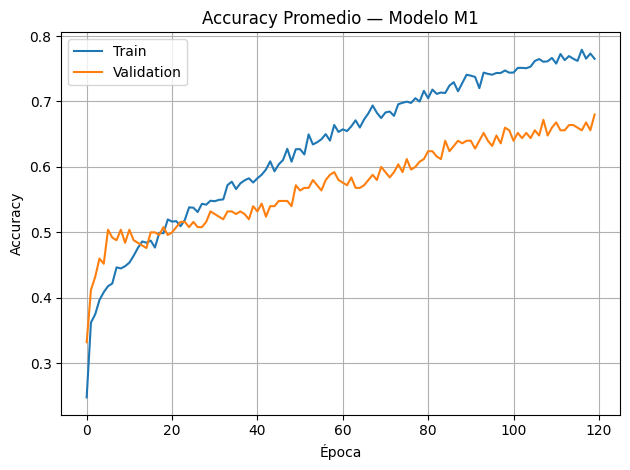

Graficas para el modelo M2


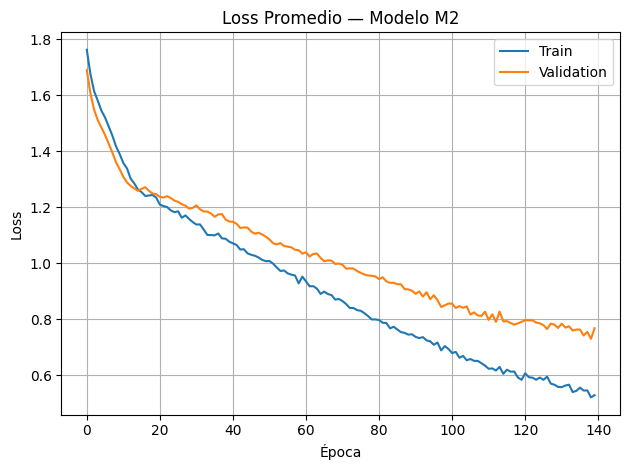

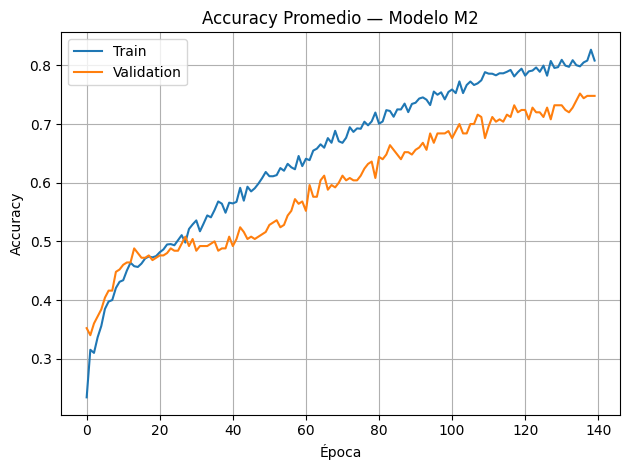

Graficas para el modelo M3


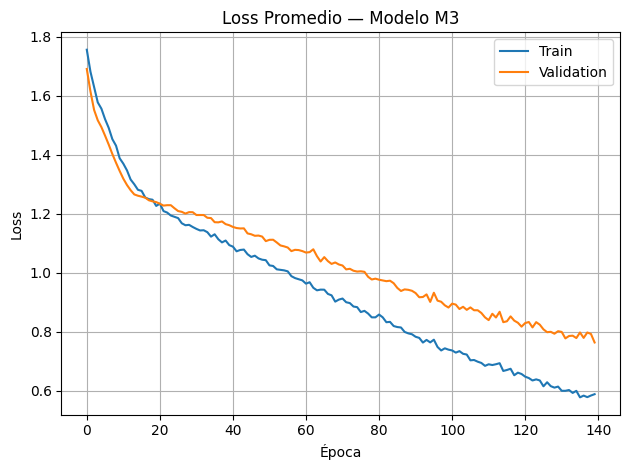

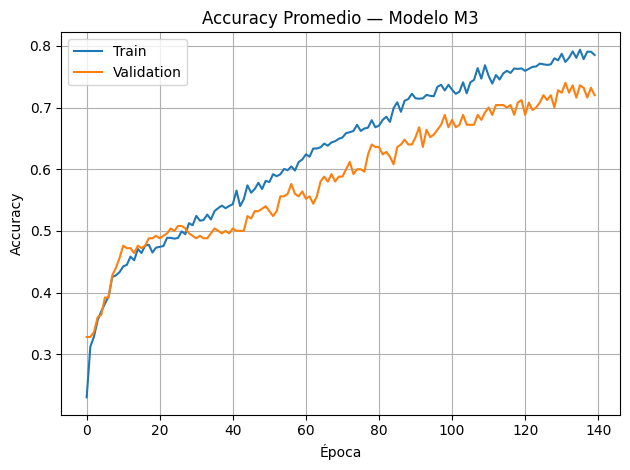

Graficas para el modelo M4


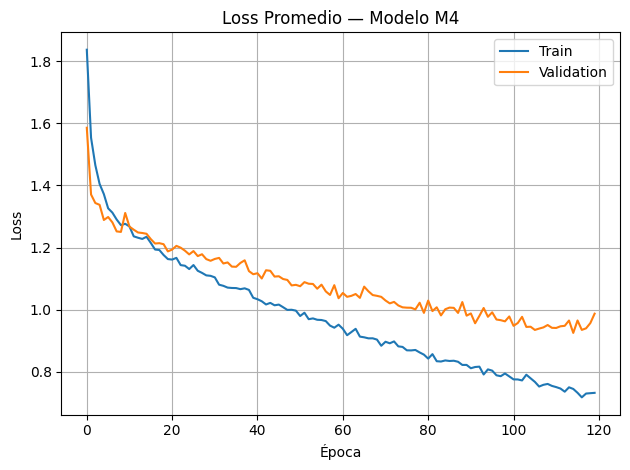

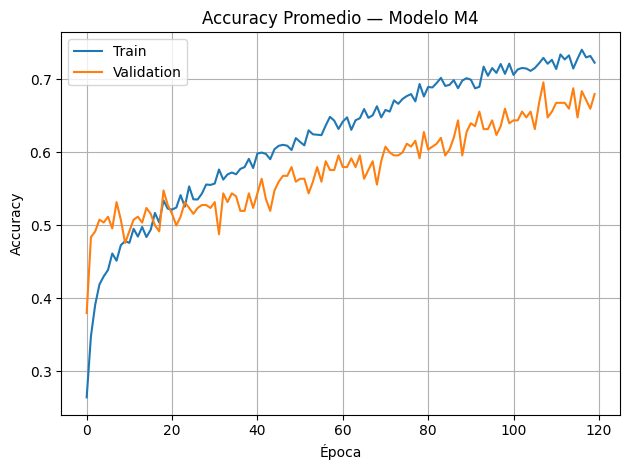

In [26]:
model_files = {
    "P1_M": "metrics_Modelo_P1_M.csv",
    "PA_M": "metrics_Modelo_PA_M.csv",
    "M1": "metrics_Modelo_M1.csv",
    "M2": "metrics_Modelo_M2.csv",
    "M3": "metrics_Modelo_M3.csv",
    "M4": "metrics_Modelo_M4.csv",
}

def plot_model_metrics(model_name, csv_path):

    df = pd.read_csv(csv_path)

    # Promedio por época (consolidando folds)
    mean_epoch = df.groupby("epoch").mean(numeric_only=True)

    #LOSS 
    plt.figure()

    plt.plot(mean_epoch["train_loss"], label="Train")
    plt.plot(mean_epoch["val_loss"], label="Validation")

    plt.title(f"Loss Promedio — Modelo {model_name}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

    # ACCURACY 
    if "train_accuracy" in mean_epoch.columns:

        plt.figure()

        plt.plot(mean_epoch["train_accuracy"], label="Train")
        plt.plot(mean_epoch["val_accuracy"], label="Validation")

        plt.title(f"Accuracy Promedio — Modelo {model_name}")
        plt.xlabel("Época")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

# EJECUCIÓN AUTOMÁTICA

for model_name, csv_file in model_files.items():
    print(f"Graficas para el modelo {model_name}")
    plot_model_metrics(model_name, csv_file)

## GRAFICO DE MARTRIZ DE CONFUSIÓN

Graficas para el modelo PA


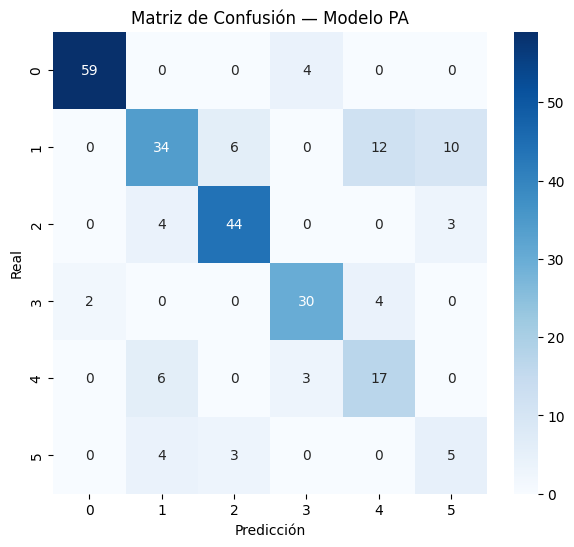

Graficas para el modelo P1


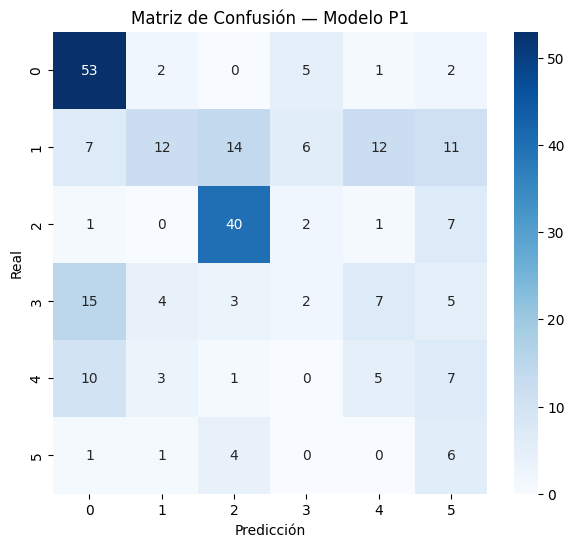

Graficas para el modelo M3


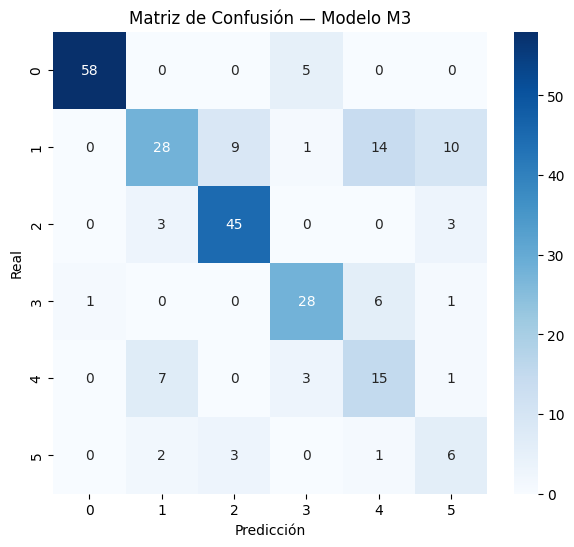

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

model_files = {
    "PA": "confusion_Modelo_PA_M.csv",
    "P1": "confusion_Modelo_P1_M.csv",
    "M3": "confusion_Modelo_M3.csv"
}

def plot_model_confusion(model_name, csv_path):
  df = pd.read_csv(csv_path)

  cm = confusion_matrix(df['y_true'], df['y_pred'])

  plt.figure(figsize=(7,6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.title(f"Matriz de Confusión — Modelo {model_name}")
  plt.xlabel("Predicción")
  plt.ylabel("Real")
  plt.show()


for model_name, csv_file in model_files.items():
    print(f"Graficas para el modelo {model_name}")
    plot_model_confusion(model_name, csv_file)


## **FUNCIÓN DE CLASIFICACIÓN DE MUETRAS**

In [28]:
def classify_individual_samples(ruta_csv, model, scaler, bandas, category_map, device=None, csv_salida="resultados_predicciones.csv"):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Cargar y predecir
    df = pd.read_csv(ruta_csv)

    pytorch_model = model.model if hasattr(model, 'model') else model
    pytorch_model.to(device)
    pytorch_model.eval()

    X = df[bandas].values.astype(np.float32)
    if scaler is not None:
        X = scaler.transform(X)

    X_tensor = torch.FloatTensor(X).to(device)
    with torch.no_grad():
        outputs = pytorch_model(X_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

    # Crear DataFrame limpio
    resultados = pd.DataFrame()
    resultados['Muestra'] = df['Apple'] if 'Apple' in df.columns else [f"M{i+1}" for i in range(len(df))]

    # Mapear clases
    reverse_map = {v: k for k, v in category_map_mush.items()}
    resultados['Clase_Predicha'] = [reverse_map[p.item()] for p in predicted]
    resultados['Confianza'] = probabilities.max(dim=1)[0].cpu().numpy()

    # Probabilidades
    for clase, idx in category_map_mush.items():
        resultados[f'P_{clase[:3]}'] = probabilities[:, idx].cpu().numpy()  # P_Opt, P_Est, P_Ace

    # Guardar
    resultados.to_csv(csv_salida, index=False)

    # Mostrar resumen rápido
    print(f"{len(resultados)} muestras clasificadas")
    print(f"Guardado en: {csv_salida}")
    print("\nVista previa:")
    print(resultados.head(10).to_string(index=False))

    return resultados

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


resultados = classify_individual_samples(
    ruta_csv="test_rapido.csv",
    model=trained_models['Modelo_PA_M'],
    scaler=scaler,
    bandas=spectral_bands,
    category_map=category_map_mush,
    device=device,
    csv_salida="clasificacion_muestras_PA_M.csv" 
)

10 muestras clasificadas
Guardado en: clasificacion_muestras_PA_M.csv

Vista previa:
Muestra Clase_Predicha  Confianza    P_Exc    P_Raz    P_Muy    P_Bue    P_Mal
     M1   Mala calidad   0.815273 0.000042 0.119577 0.001940 0.012040 0.815273
     M2       Muy mala   0.614827 0.000017 0.081502 0.000311 0.002291 0.301053
     M3      Razonable   0.495398 0.000329 0.495398 0.046529 0.078224 0.269017
     M4   Mala calidad   0.854097 0.000012 0.096742 0.000442 0.006913 0.854097
     M5      Razonable   0.656288 0.000144 0.656288 0.012805 0.300955 0.025137
     M6      Excelente   0.768655 0.768655 0.000614 0.221281 0.009307 0.000083
     M7          Buena   0.808108 0.001487 0.093735 0.093643 0.808108 0.002471
     M8      Muy buena   0.902374 0.074696 0.004311 0.902374 0.013911 0.003512
     M9       Muy mala   0.841217 0.000037 0.066471 0.000382 0.002800 0.089093
    M10      Muy buena   0.492140 0.022815 0.052223 0.492140 0.426730 0.005707


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
